
<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 4
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consignas

En esta tarea continuaremos con el capítulo 14 de Holton. DSP Principles and App.

**1. Generación de la señal**

Comenzaremos con la generación de la siguiente señal:
   $$x(k) = a_0 \cdot \operatorname{sen}(\Omega_1 \cdot n) + n_a(n)$$
Donde los parámetros son:
- $a_0 = 2$
- $\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$
- $\Omega_0 = \frac{\pi}{2}$

Siendo las variables aleatorias definidas por las siguientes distribuciones de probabilidad:
- $f_r \sim \mathcal{U}(-2, 2)$ (Distribución Uniforme)
- $n_a \sim \mathcal{N}(0, \sigma^2)$ (Distribución Normal)

**2. Diseño de Estimadores**

Diseñe los siguientes estimadores para cada una de las ventanas analizadas:

Estimador de amplitud $a_1$
$$\hat{a}_1^i = |X_w^i(\Omega_0)| = |\mathcal{F}\{x(n) \cdot w_i(n)\}|$$

Estimador de frecuencia $\Omega_1$
$$\hat{\Omega}_1^i = \arg \max_{f} \{|X_w^i(\Omega)|\}$$

**3. Ventanas a utilizar**

Para cada experimento, considere las siguientes ventanas:
- rectangular (sin ventana)
- flattop
- blackmanharris
- otra que elija de scipy.signal.windows

**4. Consignas para la experimentación**
- Considere 200 realizaciones (muestras tomadas de $f_r$) de 1000 muestras para cada experimento.
- Parametrice para SNR's de 3 y 10 dB.Ayuda: Calibre $a_1$ para que la potencia de la senoidal sea $1 \text{ W}$.

Se pide:

Realizar una tabla por cada SNR que describa el sesgo y la varianza de cada estimador para cada ventana analizada. Recuerde incluir las ventanas rectangular (sin ventana), flattop, blackmanharris y otras que considere.

**Ayuda:** Puede calcular experimentalmente el sesgo y la varianza de un estimador:
$$\hat{a}_0 = |X_w^i(\Omega_0)|$$
siendo:
$$s_a = E\{\hat{a}_0\} - a_0$$
$$v_a = var\{\hat{a}_0\} = E\{(\hat{a}_0 - E\{\hat{a}_0\})^2\}$$

y pueden aproximarse cuando consideramos los valores esperados como las medias muestrales:
$$E\{\hat{a}_0\} = \hat{\mu}_a = \frac{1}{M} \sum_{j=0}^{M-1} \hat{a}_j$$
$$s_a = \hat{\mu}_a - a_0$$
$$v_a = \frac{1}{M} \sum_{j=0}^{M-1} (\hat{a}_j - \hat{\mu}_a)^2$$

# Resolución

En primer lugar, se generó la señal discreta $x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)$ simulando 200 realizaciones en base a las especificaciones de la consigna para las variables $a_0$, $\Omega_1$, $\Omega_0$, $f_r$ y el ruido $n_a$. Para este análisis inicial, se configuró un entorno con un SNR de $10\text{ dB}$.

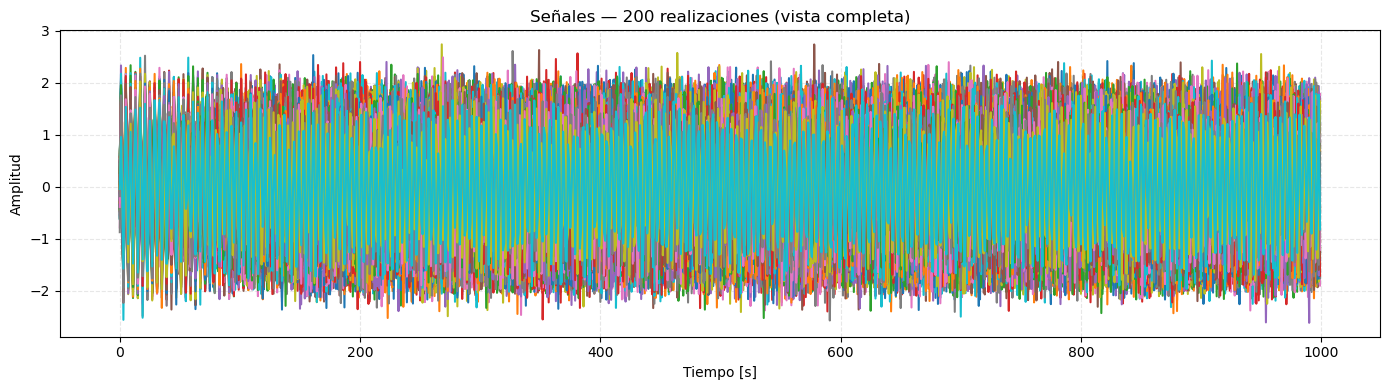

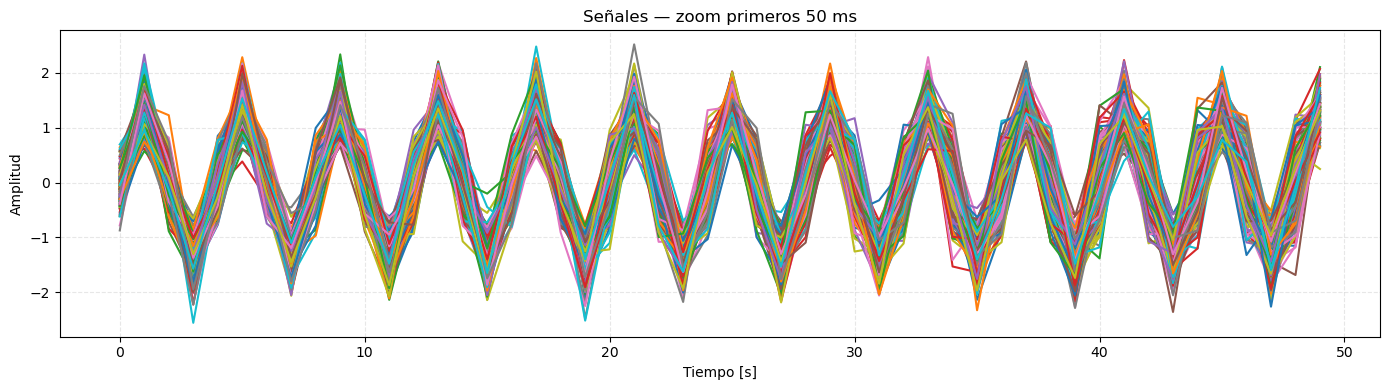

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

N = 1000
R = 200
fs = 1000
ts = 1/fs
vmax =  np.sqrt(2) # Para que la potencia de la senoidal sea 1W

omega_0 = fs/4

np.random.seed(3)

fr = np.random.uniform(-2, 2, R).reshape((R,1))

omega_1 = omega_0 + fr * (fs / N) 
omega = np.tile(omega_1, N) 

tt = (np.arange(0,N)*ts).reshape((1, N))

nn = np.tile(tt, (R,1)) 

SNR = 10
sigma = 10**(-SNR /20)
mu=0

na = np.random.normal(mu, sigma, (R,N)) 

xx = vmax * np.sin(np.pi*2*omega*nn) + na

# Vista completa
plt.figure(figsize=(14, 4))
plt.plot(xx.T)
plt.title('Señales — 200 realizaciones (vista completa)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Zoom: primeros 50 ms para ver mejor la forma de las señales
zoom_end = int(0.05 * fs)
plt.figure(figsize=(14, 4))
plt.plot(xx[:, :zoom_end].T)
plt.title('Señales — zoom primeros 50 ms')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
 
plt.show()

Una vez generadas las señales para las 200 realizaciones, se procedió a diseñar las distintas ventanas temporales requeridas, incorporando la ventana de Hamming al análisis. Con el propósito de predecir el comportamiento teórico de los estimadores de amplitud frente a los desvíos de frecuencia, se confeccionó el siguiente gráfico espectral comparativo.

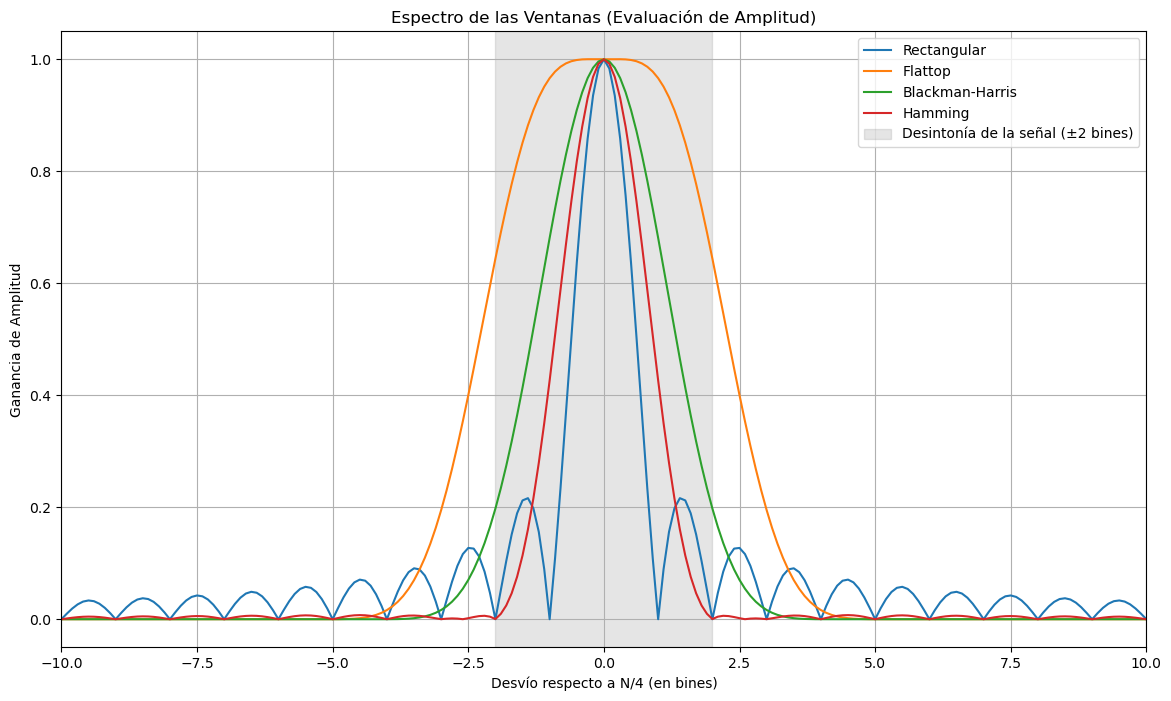

In [21]:
# Ventana rectangular 
win_rec = np.ones(N)

# Ventana flattop 
win_ft = windows.flattop(N)

# Ventana Blackmanharris 
win_bh = windows.blackmanharris(N)

# Ventana Hamming 
win_hm = windows.hamming(N)

# Grafico ventanas ------------------------------------------------------------

# Usamos mucho zero-padding para ver la curva espectral suave
N_pad = N * 10
df = fs / N_pad

# 2. Armamos los índices con arange (asumiendo que N_pad es par)
k_pos = np.arange(0, N_pad // 2)      # Índices positivos: 0, 1, 2...
k_neg = np.arange(-N_pad // 2, 0)     # Índices negativos: -N/2, -N/2+1... -1

# 3. Concatenamos y multiplicamos por df
freqs_pad = np.concatenate((k_pos, k_neg)) * df

bins_pad = freqs_pad * N / fs # Eje X convertido a "bines relativos"

# FFT de las ventanas normalizadas
W_rec = np.fft.fftshift(np.abs(np.fft.fft(win_rec, N_pad)) / N)
W_ft = np.fft.fftshift(np.abs(np.fft.fft(win_ft, N_pad)) / cg_ft)
W_bh = np.fft.fftshift(np.abs(np.fft.fft(win_bh, N_pad)) / cg_bh)
W_hm = np.fft.fftshift(np.abs(np.fft.fft(win_hm, N_pad)) / cg_hm)

# Eje X para que quede centrado
bins_pad_shift = np.fft.fftshift(bins_pad)

plt.figure(2, figsize=(14, 8))
plt.plot(bins_pad_shift, W_rec, label='Rectangular')
plt.plot(bins_pad_shift, W_ft, label='Flattop')
plt.plot(bins_pad_shift, W_bh, label='Blackman-Harris')
plt.plot(bins_pad_shift, W_hm, label='Hamming')

# Área donde caen las frecuencias aleatorias (-2 a 2 bines)
plt.axvspan(-2, 2, color='gray', alpha=0.2, label='Desintonía de la señal (±2 bines)')

plt.xlim(-10, 10)
plt.title('Espectro de las Ventanas (Evaluación de Amplitud)')
plt.xlabel('Desvío respecto a N/4 (en bines)')
plt.ylabel('Ganancia de Amplitud')
plt.legend()
plt.grid(True)
plt.show()

Como puede observarse, para el caso de la ventana rectangular, la curva cae a cero en los bines ±1 y ±2. Como la frecuencia de la señal cae aleatoriamente en cualquier punto dentro de la franja gris, es problable que varias veces al evaluar nos encontremos justo en esos "pozos" de ganancia nula. Resultando en un sesgo alto. 

Para el resto de ventanas la situacion mejora, siendo la mas favorable el caso de la ventana flattop. Debido a su forma de campana ancha, en el centro es casi completamente plana y recién empieza a caer suavemente hacia los bordes de la zona gris. Al promediar todas las mediciones aleatorias ahí adentro, la pérdida de amplitud es mínima. Resultando en un sesgo minimo. 

### Cálculo de los estimadores

Para estimar correctamente la amplitud de la componente senoidal bajo el efecto de diferentes funciones de ventaneo, es necesario compensar la atenuación de energía introducida por la forma de la ventana en el dominio del tiempo.

Consideremos un tono puro discreto de amplitud $a_0$ y frecuencia angular $\Omega_0$:
$$x(n) = a_0 \cdot \sin(\Omega_0 \cdot n)$$
Haciendo uso de la identidad de Euler, la señal puede expresarse en términos de sus componentes exponenciales complejas como:
$$x(n) = a_0 \cdot \frac{e^{j\Omega_0 n} - e^{-j\Omega_0 n}}{2j}$$
Al aplicar una función de ventaneo $w(n)$ de longitud $N$ y calcular la Transformada Discreta de Fourier (DFT), la respuesta espectral evaluada exactamente en la frecuencia de la señal $\Omega_0$ resulta:
$$X_w(\Omega_0) = \sum_{n=0}^{N-1} x(n) \cdot w(n) \cdot e^{-j\Omega_0 n}$$
Sustituyendo la expresión analítica de la señal y aislando el aporte de la componente de frecuencia positiva (despreciando la contribución de frecuencias negativas) se obtiene:
$$X_w(\Omega_0) \approx \sum_{n=0}^{N-1} \left( \frac{a_0}{2j} e^{j\Omega_0 n} \right) \cdot w(n) \cdot e^{-j\Omega_0 n}$$
Dado que el producto de las exponenciales complejas conjugadas es la unidad ($e^{j\Omega_0 n} \cdot e^{-j\Omega_0 n} = 1$), la sumatoria se reduce exclusivamente a la combinación lineal de los coeficientes de la ventana:
$$X_w(\Omega_0) \approx \frac{a_0}{2j} \sum_{n=0}^{N-1} w(n)$$
Aplicando el operador módulo para obtener la magnitud espectral (donde $|1/j| = 1$), la ecuación queda definida de la siguiente manera:
$$|X_w(\Omega_0)| = \frac{a_0}{2} \sum_{n=0}^{N-1} w(n)$$
Finalmente, despejando la amplitud real del tono $a_0$, se deduce matemáticamente la expresión para el estimador óptimo de amplitud ($\hat{a}_0$):
$$\hat{a}_0 = \frac{2 \cdot |X_w(\Omega_0)|}{\sum_{n=0}^{N-1} w(n)}$$

La derivación demuestra que para recuperar la amplitud física de una señal senoidal tras el proceso de ventaneo, el factor de normalización espectral está estrictamente condicionado por la suma de todos los coeficientes de la ventana utilizada.En el caso particular de la ventana rectangular, donde $w(n) = 1$ para todo $n$, la sumatoria es igual a $N$, reduciendo la expresión al clásico factor $2/N$. Sin embargo, para ventanas no rectangulares (tales como Hamming, Blackman-Harris o Flattop), omitir esta sumatoria e indexar la DFT utilizando el factor de la ventana rectangular introduce un error de escala sistemático que invalida la comparación estadística de los estimadores.

In [40]:
# Para la ventana rectangular -------------------------------------------------
xx_rec = xx * win_rec
X_rec = np.fft.fft(xx_rec, N, axis=1) / N

k0 = int(N * (omega_0 / fs))  # = N//4 
X_rec_k0 = X_rec[:, k0] # FFT evaluada en N/4

# ---- Estamacion amplitud ----
amp_rec = (np.abs(X_rec_k0)) * 2 # amplitud evaluar la X en N/4
ses_amp_rec = np.mean(amp_rec) - np.sqrt(2) 
var_amp_rec = np.var(amp_rec)

#---- Estamacion frecuencia ----
X_rec_max = np.argmax(np.abs(X_rec[:, :N//2]), axis=1)
frec_rec = X_rec_max * fs/N
ses_frec_rec = np.mean(frec_rec - omega_1.flatten())
var_frec_rec = np.var(frec_rec)

# Para la ventana flattop -----------------------------------------------------
xx_ft = xx * win_ft

X_ft = np.fft.fft(xx_ft, N, axis=1) / np.sum(win_ft)

k0 = int(N * (omega_0 / fs))
X_ft_k0 = X_ft[:, k0] 

# ---- Estamacion amplitud ----
amp_ft = (np.abs(X_ft_k0)) * 2
ses_amp_ft = np.mean(amp_ft) - np.sqrt(2) 
var_amp_ft = np.var(amp_ft)

#---- Estamacion frecuencia ----
X_ft_max = np.argmax(np.abs(X_ft[:, :N//2]), axis=1)
frec_ft = X_ft_max * fs/N
ses_frec_ft = np.mean(frec_ft - omega_1.flatten())
var_frec_ft = np.var(frec_ft)

# Para la ventana Blackmanharris ----------------------------------------------
xx_bh = xx * win_bh

X_bh = np.fft.fft(xx_bh, N, axis=1) / np.sum(win_bh)

k0 = int(N * (omega_0 / fs))
X_bh_k0 = X_bh[:, k0] 

# ---- Estamacion amplitud ----
amp_bh = (np.abs(X_bh_k0)) * 2
ses_amp_bh = np.mean(amp_bh) - np.sqrt(2) 
var_amp_bh = np.var(amp_bh)

#---- Estamacion frecuencia ----
X_bh_max = np.argmax(np.abs(X_bh[:, :N//2]), axis=1)
frec_bh = X_bh_max * fs/N
ses_frec_bh = np.mean(frec_bh - omega_1.flatten())
var_frec_bh = np.var(frec_bh)

# Para la ventana Hamming -----------------------------------------------------
xx_hm = xx * win_hm

X_hm = np.fft.fft(xx_hm, N, axis=1) / np.sum(win_hm)

k0 = int(N * (omega_0 / fs))
X_hm_k0 = X_hm[:, k0] 

# ---- Estamacion amplitud ----
amp_hm = (np.abs(X_hm_k0)) * 2
ses_amp_hm = np.mean(amp_hm) - np.sqrt(2) 
var_amp_hm = np.var(amp_hm)

#---- Estamacion frecuencia ----
X_hm_max = np.argmax(np.abs(X_hm[:, :N//2]), axis=1)
frec_hm = X_hm_max * fs/N
ses_frec_hm = np.mean(frec_hm - omega_1.flatten())
var_frec_hm = np.var(frec_hm)


print("=== Estimación de Amplitud ===")
print(f"{'Ventana':<20} {'Sesgo (sa)':>15} {'Varianza (va)':>15}")
print(f"{'Rectangular':<20} {ses_amp_rec:>15.6f} {var_amp_rec:>15.6f}")
print(f"{'Flat-top':<20} {ses_amp_ft:>15.6f} {var_amp_ft:>15.6f}")
print(f"{'Blackman-Harris':<20} {ses_amp_bh:>15.6f} {var_amp_bh:>15.6f}")
print(f"{'Hamming':<20} {ses_amp_hm:>15.6f} {var_amp_hm:>15.6f}")

print("\n=== Estimación de Frecuencia ===")
print(f"{'Ventana':<20} {'Sesgo (sa)':>15} {'Varianza (va)':>15}")
print(f"{'Rectangular':<20} {ses_frec_rec:>15.6f} {var_frec_rec:>15.6f}")
print(f"{'Flat-top':<20} {ses_frec_ft:>15.6f} {var_frec_ft:>15.6f}")
print(f"{'Blackman-Harris':<20} {ses_frec_bh:>15.6f} {var_frec_bh:>15.6f}")
print(f"{'Hamming':<20} {ses_frec_hm:>15.6f} {var_frec_hm:>15.6f}")

=== Estimación de Amplitud ===
Ventana                   Sesgo (sa)   Varianza (va)
Rectangular                -0.906039        0.207485
Flat-top                   -0.112618        0.018734
Blackman-Harris            -0.479908        0.126877
Hamming                    -0.751671        0.236526

=== Estimación de Frecuencia ===
Ventana                   Sesgo (sa)   Varianza (va)
Rectangular                 0.008062        1.470000
Flat-top                    0.023062        1.474775
Blackman-Harris             0.008062        1.470000
Hamming                     0.008062        1.470000


Con los valores obtenidos, podemos hacer un grafico comparativo, para visualizar mejor las diferencias entre los estimadores de ampllitud para cada caso.

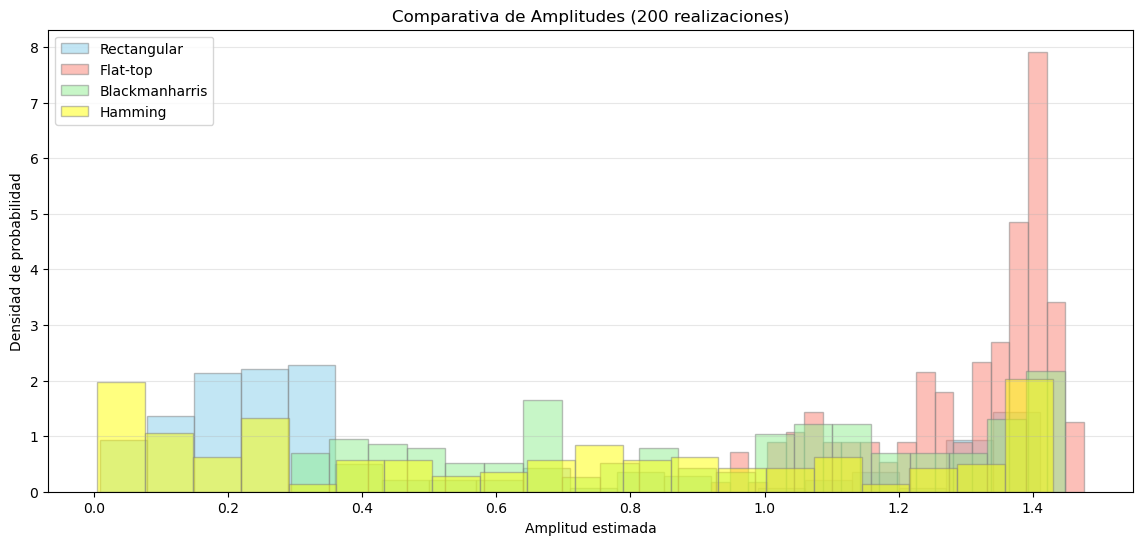

In [38]:
# ---- Estamacion amplitud ----
plt.figure(3, figsize=(14, 6))
plt.hist(amp_rec, bins=20, color='skyblue', edgecolor='grey', 
         alpha=0.5, label='Rectangular', density=True)

plt.hist(amp_ft, bins=20, color='salmon', edgecolor='grey', 
         alpha=0.5, label='Flat-top', density=True)

plt.hist(amp_bh, bins=20, color='lightgreen', edgecolor='grey', 
         alpha=0.5, label='Blackmanharris', density=True)

plt.hist(amp_hm, bins=20, color='yellow', edgecolor='grey', 
         alpha=0.5, label='Hamming', density=True)

plt.title(f'Comparativa de Amplitudes ({R} realizaciones)')
plt.xlabel('Amplitud estimada')
plt.ylabel('Densidad de probabilidad')
plt.legend() 
plt.grid(axis='y', alpha=0.3)

Se puede observar como el caso con la ventana flattop presenta un pico bastante marcado en 1.41 que es $\approx\sqrt{2}$, la amplitud que definimos al generar las señales. Como se vió en el grafico de los espectros de las ventanas, esto se debe a la geometría de su lóbulo principal. Como su nombre lo indica, el tope de su espectro es completamente plano en la zona de desintonía de $\pm 2$ bines. No importa hacia dónde se mueva la frecuencia real de la señal por la variable aleatoria $f_r$, la ganancia que ve el bin fijo $N/4$ casi siempre es un $1$ exacto ($0\text{ dB}$). 

Las ventanas Rectangular (azul), Hamming (amarillo) y Blackman-Harris (verde) muestran una distribución completamente "esparcida" y achatada que se extiende desde el valor correcto ($1.414$) descendiendo casi hasta $0$. Al obligar al estimador a evaluar rígidamente en el bin fijo $N/4$, cualquier desvío en la frecuencia real ($f_r$) hace que empecemos a muestrear los "costados" del lóbulo principal de la ventana. Siendo el peor de los casos el de la ventana rectangular, donde existe la posibilidad de que para algunas realizaciones la amplitud estimada caiga abruptamente a cero.

### Comparando con SNR = 3 dB

A continuacion se presentan las tablas comparativas de los estimadores para un SNR de 10dB y otro de 3dB.

In [48]:

for SNR in [10, 3]:
    sigma = 10**(-SNR / 20)
    na = np.random.normal(0, sigma, (R, N))
    xx = vmax * np.sin(np.pi * 2 * omega * nn) + na

    windows = [
        ('Rectangular',     win_rec, N),
        ('Flat-top',        win_ft,  np.sum(win_ft)),
        ('Blackman-Harris', win_bh,  np.sum(win_bh)),
        ('Hamming',         win_hm,  np.sum(win_hm)),
    ]

    k0 = int(N * (omega_0 / fs))
    results = {}

    for name, win, norm in windows:
        X = np.fft.fft(xx * win, N, axis=1) / norm
        amp  = np.abs(X[:, k0]) * 2
        frec = np.argmax(np.abs(X[:, :N//2]), axis=1) * fs / N
        results[name] = {
            'ses_amp':  np.mean(amp) - np.sqrt(2),
            'var_amp':  np.var(amp),
            'ses_frec': np.mean(frec - omega_1.flatten()),
            'var_frec': np.var(frec),
        }

    print(f"\n\n===================== SNR: {SNR} =====================")
    print(f"\n  Estimación de amplitud")
    print(f"  {'Ventana':<20} {'s_a':>12} {'v_a':>12}")
    print(f"  {'-'*44}")
    for name, r in results.items():
        print(f"  {name:<20} {r['ses_amp']:>12.6f} {r['var_amp']:>12.6f}")

    print(f"\n  Estimación de frecuencia")
    print(f"  {'Ventana':<20} {'s_a':>12} {'v_a':>12}")
    print(f"  {'-'*44}")
    for name, r in results.items():
        print(f"  {name:<20} {r['ses_frec']:>12.6f} {r['var_frec']:>12.6f}")



===================== SNR: 10 =====================

  Estimación de amplitud
  Ventana                       s_a          v_a
  --------------------------------------------
  Rectangular             -0.906327     0.207471
  Flat-top                -0.112923     0.019622
  Blackman-Harris         -0.480143     0.127685
  Hamming                 -0.751966     0.236947

  Estimación de frecuencia
  Ventana                       s_a          v_a
  --------------------------------------------
  Rectangular              0.018062     1.449900
  Flat-top                 0.013062     1.454975
  Blackman-Harris          0.008062     1.440000
  Hamming                  0.013062     1.434975


===================== SNR: 3 =====================

  Estimación de amplitud
  Ventana                       s_a          v_a
  --------------------------------------------
  Rectangular             -0.905644     0.204951
  Flat-top                -0.105178     0.020234
  Blackman-Harris         -0.476642

Se puede observar que si bien bajó la relación señal a ruido (es decir, se le sumó más ruido a la señal), pero los resultados son prácticamente iguales. Los sesgos y las varianzas apenas se movieron unas milésimas. Esto se debe a que si bien el ruido gaussiano agregado afecta, el error que genera evaluar la FFT en el bin equivocado es tan grande que "tapa" completamente al error introducido por el ruido.

Se puede notar que la varianza de la frecuencia siempre ronda $1.41$. Esto tiene una explicación matemática directa. La señal tiene una desintonía que sigue una distribución uniforme entre $-2$ y $2$ bines. La varianza teórica de una distribución uniforme continua está dada por la fórmula $\frac{(b-a)^2}{12}$. Si aplicamos los valores de nuestro caso:
$$\text{Varianza} = \frac{(2 - (-2))^2}{12} = \frac{16}{12} \approx 1.33$$
Como el código busca la frecuencia usando np.argmax() (solo devuelve números enteros), se está forzando a que la medición salte de a 1 bin entero, mientras que la señal real se mueve en decimales. Esa cuantización, sumada a la varianza natural de $1.33$ de la distribución aleatoria, más la pequeña cuota del ruido, da como resultado el $\sim 1.4$.

# Conclusiones generales

A lo largo de este trabajo se analizó el comportamiento de estimadores de amplitud y frecuencia basados en la DFT, aplicados a una señal senoidal con frecuencia aleatoria en presencia de ruido aditivo gaussiano. Los resultados permiten extraer conclusiones claras sobre el impacto de la elección de la ventana en el desempeño estadístico de cada estimador.

**Respecto a la estimación de amplitud**, la ventana *flat-top* se posicionó como la única opción con sesgo prácticamente nulo. Esto se explica directamente por la geometría de su lóbulo principal: al ser completamente plano en la región de $\pm2$ bines, la ganancia que percibe el bin fijo $N/4$ es prácticamente igual a la unidad (0 dB) independientemente de la desintonía introducida por $f_r$. Las ventanas Blackman-Harris, Hamming y rectangular, en cambio, exhibieron un sesgo elevado y alta varianza, ya que al evaluar la FFT en un bin fijo cuando la señal real "cae entre bines", se muestrea el costado del lóbulo principal, subestimando sistemáticamente la amplitud. En el caso extremo de la ventana rectangular, la existencia de ceros en $\pm1$ y $\pm2$ bines puede llevar la amplitud estimada a valores cercanos a cero.

**Respecto a la estimación de frecuencia**, todas las ventanas presentaron una varianza de aproximadamente $1.41$. Este valor no es aleatorio: se corresponde con la varianza teórica de la distribución uniforme $\mathcal{U}(-2, 2) \approx1.33$, más la contribución de la cuantización inherente al uso de np.argmax() (solo devuelve índices enteros) y el pequeño aporte del ruido gaussiano. Esta invarianza respecto a la ventana elegida indica que el error en la estimación de frecuencia no es consecuencia de la ventana sino de la resolución espectral fija y de la naturaleza discreta del estimador.

**Respecto al efecto del SNR**, al comparar los resultados para 10 dB y 3 dB se observó que los sesgos y varianzas variaron apenas en milésimas. Esto evidencia que el error dominante en este escenario no proviene del ruido, sino de la evaluación en el bin equivocado. La pérdida de amplitud por desintonía supera ampliamente al error introducido por el ruido, enmascarando cualquier degradación por SNR. 

En síntesis, la elección de la ventana implica una disyuntiva fundamental entre resolución espectral y precisión en la estimación de amplitud. La ventana flat-top es la herramienta obligatoria cuando la prioridad es medir amplitudes con incertidumbre en la frecuencia, aunque su lóbulo ancho la vuelve inadecuada para separar componentes espectrales cercanas. Las demás ventanas ofrecen mejor resolución frecuencial a costa de mayor sesgo en amplitud. Comprender este compromiso es esencial para el diseño de sistemas de medición basados en la DFT.